# 18 — GLOBE Patches + GCD (clearsky/mixed), ImageNet Init

Mimics the CloudDenseNet pipeline in notebook 15, with two changes:

1. **Data replacement** — the five GCD cloud types that map directly to NASA
   GLOBE classes (cumulus→Cu, altocumulus→Ac, cirrus→Ci, stratocumulus→Sc,
   cumulonimbus→Cb) are replaced with **proportional 224×224 patches** extracted
   from raw NASA GLOBE images.  Images are first filtered at 99 % cloud
   confidence via the ResNet18 CSV (like notebook 16), then each extracted
   patch is filtered at 50 % confidence (like notebook 17).

2. **GCD-only classes** — `4_clearsky` and `7_mixed` have no GLOBE equivalent
   and are loaded straight from the GCD train/test split as full images.

The backbone is DenseNet121 from **ImageNet weights** (no GCD pre-training).
Training follows notebook 15's 5-phase gradual-unfreeze schedule.

| Phase | Layers | Head LR | Backbone LR | Epochs |
|-------|--------|---------|-------------|--------|
| 1 | TopBlock only | 1e-4 | — | 10 |
| 2 | TopBlock only | 1e-5 | — | 10 |
| 3 | TopBlock + DenseBlock3+ | 1e-5 | 5e-5 | 20 |
| 4 | TopBlock + DenseBlock3+ | 1e-5 | 1e-5 | 20 |
| 5 | All layers | 1e-6 | 1e-6 | 20 |

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from collections import Counter

GCD_ROOT         = Path('../resources/cloud-images/GCD')
GCD_ONLY_CLASSES = {'4_clearsky', '7_mixed'}

def index_gcd_split(split_dir):
    paths, labels = [], []
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        label = class_dir.name
        if label not in GCD_ONLY_CLASSES:
            continue
        for img_path in sorted(class_dir.glob('*.jpg')):
            paths.append(str(img_path))
            labels.append(label)
    return np.array(paths), np.array(labels)

gcd_train_paths_raw, gcd_train_labels_raw = index_gcd_split(GCD_ROOT / 'train')
gcd_test_paths_raw,  gcd_test_labels_raw  = index_gcd_split(GCD_ROOT / 'test')

print('GCD (clearsky + mixed only):')
for split_name, lbl in [('train', gcd_train_labels_raw), ('test', gcd_test_labels_raw)]:
    print(f'  {split_name}:')
    for cls, cnt in sorted(Counter(lbl).items()):
        print(f'    {cls:25s}  {cnt:,}')
    print(f'    {"TOTAL":25s}  {len(lbl):,}')

GCD (clearsky + mixed only):
  train:
    4_clearsky                 2,150
    7_mixed                    348
    TOTAL                      2,498
  test:
    4_clearsky                 1,589
    7_mixed                    607
    TOTAL                      2,196


In [29]:
CSV_PATH    = Path('../resources/cloud-images/NASA_GLOBE_CD/cloud_filter_results_1.csv')
IMAGES_ROOT = Path('../resources/cloud-images/NASA_GLOBE_CD/downloaded_images')

# Only the 5 GLOBE classes that match GCD; values are the GCD label names
GLOBE_TO_GCD = {
    'Ac': '2_altocumulus',
    'Cb': '6_cumulonimbus',
    'Ci': '3_cirrus',
    'Cu': '1_cumulus',
    'Sc': '5_stratocumulus',
}

def index_globe_filtered(csv_path, globe_to_gcd, images_root,
                          conf_threshold=0.99, max_per_class=3000):
    df = pd.read_csv(csv_path)
    df = df.rename(columns={'cloud_conf': 'head2_conf', 'head1_class': 'head1_pred'})
    paths, labels = [], []
    for globe_cls, gcd_label in globe_to_gcd.items():
        clean = df[(df['folder'] == globe_cls) & (df['head2_conf'] >= conf_threshold)]
        clean = clean.sample(min(max_per_class, len(clean)), random_state=42)
        for _, row in clean.iterrows():
            paths.append(str(images_root / globe_cls / row['filename']))
            labels.append(gcd_label)
    return np.array(paths), np.array(labels)

globe_paths, globe_labels = index_globe_filtered(CSV_PATH, GLOBE_TO_GCD, IMAGES_ROOT)

print('NASA GLOBE (5 matching classes, translated to GCD names, conf >= 0.99):')
for cls, cnt in sorted(Counter(globe_labels).items()):
    print(f'  {cls:25s}  {cnt:,}')
print(f'  {"TOTAL":25s}  {len(globe_labels):,}')

NASA GLOBE (5 matching classes, translated to GCD names, conf >= 0.99):
  1_cumulus                  3,000
  2_altocumulus              3,000
  3_cirrus                   3,000
  5_stratocumulus            3,000
  6_cumulonimbus             3,000
  TOTAL                      15,000


In [30]:
import torch

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'device: {device}')

device: mps


In [31]:
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

IMG_SIZE = (224, 224)
MAX_FRAC = 0.14

border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

# T.Lambda is fine locally with num_workers=0
wrap_translation = T.Lambda(lambda x: torch.roll(
    x,
    shifts=(
        int(torch.randint(-int(MAX_FRAC * x.shape[-2]), int(MAX_FRAC * x.shape[-2]) + 1, (1,)).item()),
        int(torch.randint(-int(MAX_FRAC * x.shape[-1]), int(MAX_FRAC * x.shape[-1]) + 1, (1,)).item()),
    ),
    dims=(-2, -1),
))

# GCD full images: keep RandomResizedCrop (like nb15)
gcd_stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20, scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR, fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
])

# GLOBE patches are already 224x224 — no Resize or RandomResizedCrop needed
globe_stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20, scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR, fill=0
    ),
])

one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([T.RandomHorizontalFlip(p=1.0), T.RandomVerticalFlip(p=1.0)]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
])

normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

gcd_train_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([gcd_stacked, one_of]),
    normalize,
])

globe_train_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([globe_stacked, one_of]),
    normalize,
])

eval_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    normalize,
])

In [32]:
from sklearn.preprocessing import LabelEncoder

# All 7 class names: 5 from GLOBE (translated) + 2 GCD-only
ALL_CLASSES = sorted(GCD_ONLY_CLASSES | set(GLOBE_TO_GCD.values()))
le = LabelEncoder()
le.fit(ALL_CLASSES)

class_names = le.classes_
n_classes   = len(class_names)
print(f'Classes ({n_classes}): {class_names}')

Classes (7): ['1_cumulus' '2_altocumulus' '3_cirrus' '4_clearsky' '5_stratocumulus'
 '6_cumulonimbus' '7_mixed']


In [33]:
from sklearn.model_selection import StratifiedShuffleSplit

# GCD: use the existing train/test split; carve 20% val from train
gcd_train_enc = le.transform(gcd_train_labels_raw)
gcd_test_enc  = le.transform(gcd_test_labels_raw)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
gcd_tr_idx, gcd_val_idx = next(sss.split(gcd_train_paths_raw, gcd_train_enc))

gcd_split = {
    'train': (gcd_train_paths_raw[gcd_tr_idx],  gcd_train_enc[gcd_tr_idx]),
    'val':   (gcd_train_paths_raw[gcd_val_idx],  gcd_train_enc[gcd_val_idx]),
    'test':  (gcd_test_paths_raw,                gcd_test_enc),
}

print('GCD image counts (clearsky + mixed):')
for split_name, (paths, labels) in gcd_split.items():
    counts = Counter(le.inverse_transform(labels))
    print(f'  {split_name:5s}: {len(paths):,}  {dict(sorted(counts.items()))}')

# GLOBE: 70/10/20 stratified split at image level (prevents patch leakage)
globe_enc = le.transform(globe_labels)

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(sss1.split(globe_paths, globe_enc))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1 / 0.8, random_state=42)
train_rel_idx, val_rel_idx = next(
    sss2.split(globe_paths[trainval_idx], globe_enc[trainval_idx]))

globe_split = {
    'train': (globe_paths[trainval_idx[train_rel_idx]], globe_enc[trainval_idx[train_rel_idx]]),
    'val':   (globe_paths[trainval_idx[val_rel_idx]],   globe_enc[trainval_idx[val_rel_idx]]),
    'test':  (globe_paths[test_idx],                    globe_enc[test_idx]),
}

print('\nGLOBE image counts (before patch expansion):')
for split_name, (paths, _) in globe_split.items():
    print(f'  {split_name:5s}: {len(paths):,}')

GCD image counts (clearsky + mixed):
  train: 1,998  {np.str_('4_clearsky'): 1720, np.str_('7_mixed'): 278}
  val  : 500  {np.str_('4_clearsky'): 430, np.str_('7_mixed'): 70}
  test : 2,196  {np.str_('4_clearsky'): 1589, np.str_('7_mixed'): 607}

GLOBE image counts (before patch expansion):
  train: 10,500
  val  : 1,500
  test : 3,000


In [34]:
from torch.utils.data import Dataset
from PIL import Image

CROP_FRACTION = 0.5
OVERLAP       = 0.25
OUTPUT_SIZE   = 224


class PatchDataset(Dataset):
    """
    Expands each image into proportional 224x224 patches.

    Crop boxes are computed once at init (reads only image headers).
    Pixel data is loaded lazily in __getitem__.
    Each patch inherits its parent image's label.
    """
    def __init__(self, paths, encoded_labels,
                 crop_fraction=0.5, overlap=0.25, output_size=224,
                 transform=None):
        self.output_size = output_size
        self.transform   = transform
        self.samples     = []  # (path, label_int, (x0, y0, x1, y1))

        for path, label in zip(paths, encoded_labels):
            try:
                W, H = Image.open(path).size
            except Exception:
                continue
            crop_size = max(output_size, int(min(W, H) * crop_fraction))
            stride    = int(crop_size * (1 - overlap))
            for y in range(0, H - crop_size + 1, stride):
                for x in range(0, W - crop_size + 1, stride):
                    self.samples.append((path, label, (x, y, x + crop_size, y + crop_size)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, box = self.samples[idx]
        img  = Image.open(path).convert('RGB')
        crop = img.crop(box).resize((self.output_size, self.output_size), Image.BILINEAR)
        if self.transform:
            crop = self.transform(crop)
        return crop, label


print('Building GLOBE patch datasets (reading image headers)...')
globe_train_patches = PatchDataset(
    globe_split['train'][0], globe_split['train'][1],
    CROP_FRACTION, OVERLAP, OUTPUT_SIZE, globe_train_transforms)
globe_val_patches   = PatchDataset(
    globe_split['val'][0],   globe_split['val'][1],
    CROP_FRACTION, OVERLAP, OUTPUT_SIZE, eval_transforms)
globe_test_patches  = PatchDataset(
    globe_split['test'][0],  globe_split['test'][1],
    CROP_FRACTION, OVERLAP, OUTPUT_SIZE, eval_transforms)

print(f'GLOBE patches — train: {len(globe_train_patches):,}  '
      f'val: {len(globe_val_patches):,}  test: {len(globe_test_patches):,}')
avg = len(globe_train_patches) / len(globe_split['train'][0])
print(f'Avg patches per training image: {avg:.1f}')

Building GLOBE patch datasets (reading image headers)...
GLOBE patches — train: 69,196  val: 9,902  test: 19,810
Avg patches per training image: 6.6


In [35]:
import torchvision
import torch.nn as nn
import torchvision.transforms as T_filter
import torch.nn.functional as F_filter

# TODO:
# [] Test raising cloud threshold

CLOUD_THRESHOLD = 0.99
FILTER_BATCH    = 128


class MultiHeadResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = torchvision.models.resnet18(
            weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head1 = base.fc
        self.head2 = nn.Linear(512, num_classes)
        for p in self.backbone.parameters(): p.requires_grad = False
        for p in self.head1.parameters():    p.requires_grad = False

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return self.head1(feat), self.head2(feat)


filter_ckpt    = torch.load('../models/multihead_resnet18_cloud_sky.pth',
                            map_location='cpu', weights_only=False)
filter_classes = filter_ckpt['classes']
cloud_idx      = filter_classes.index('cloud')
filter_model   = MultiHeadResNet18(num_classes=len(filter_classes))
filter_model.load_state_dict(filter_ckpt['model_state_dict'])
filter_model.eval().to(device)

filter_transform = T_filter.Compose([
    T_filter.ToTensor(),
    T_filter.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def filter_patch_samples(samples, threshold=CLOUD_THRESHOLD, batch_size=FILTER_BATCH):
    """
    Keep only patches where ResNet18 head2 cloud confidence >= threshold.
    Patches are grouped by parent image so each file is opened exactly once.
    """
    kept = []
    tensor_buf, sample_buf = [], []
    current_path, current_img = None, None

    def flush():
        if not tensor_buf:
            return
        inp = torch.stack(tensor_buf).to(device)
        with torch.no_grad():
            _, out2 = filter_model(inp)
            probs = F_filter.softmax(out2, dim=1).cpu().numpy()
        for samp, prob in zip(sample_buf, probs):
            if prob[cloud_idx] >= threshold:
                kept.append(samp)
        tensor_buf.clear()
        sample_buf.clear()

    for sample in samples:
        path, label, box = sample
        if path != current_path:
            try:
                current_img  = Image.open(path).convert('RGB')
                current_path = path
            except Exception:
                current_img  = None
                current_path = path
        if current_img is None:
            continue
        try:
            crop = current_img.crop(box).resize((OUTPUT_SIZE, OUTPUT_SIZE), Image.BILINEAR)
            tensor_buf.append(filter_transform(crop))
            sample_buf.append(sample)
        except Exception:
            pass
        if len(tensor_buf) >= batch_size:
            flush()

    flush()
    return kept


def summarise_filter(before, after, split_name):
    n_before = len(before)
    n_after  = len(after)
    kept_pct = 100 * n_after / n_before if n_before else 0
    print(f'  {split_name:5s}  {n_before:>8,} → {n_after:>8,}  ({kept_pct:.1f}% kept)')
    before_cls = Counter(s[1] for s in before)
    after_cls  = Counter(s[1] for s in after)
    for cls_idx in sorted(before_cls):
        b, a = before_cls[cls_idx], after_cls.get(cls_idx, 0)
        pct  = 100 * a / b if b else 0
        print(f'    {class_names[cls_idx]:25s}  {b:>6,} → {a:>6,}  ({pct:.1f}%)')


print(f'Patch cloud filter  threshold={CLOUD_THRESHOLD}\n')
for ds, name in [(globe_train_patches, 'train'),
                 (globe_val_patches,   'val'),
                 (globe_test_patches,  'test')]:
    before = ds.samples[:]
    ds.samples = filter_patch_samples(ds.samples)
    summarise_filter(before, ds.samples, name)
    print()

Patch cloud filter  threshold=0.99

  train    69,196 →   32,140  (46.4% kept)
    1_cumulus                  14,184 →  7,088  (50.0%)
    2_altocumulus              13,746 →  7,016  (51.0%)
    3_cirrus                   13,922 →  5,518  (39.6%)
    5_stratocumulus            13,626 →  5,582  (41.0%)
    6_cumulonimbus             13,718 →  6,936  (50.6%)

  val       9,902 →    4,585  (46.3% kept)
    1_cumulus                   2,050 →  1,044  (50.9%)
    2_altocumulus               1,992 →    950  (47.7%)
    3_cirrus                    1,980 →    775  (39.1%)
    5_stratocumulus             1,944 →    806  (41.5%)
    6_cumulonimbus              1,936 →  1,010  (52.2%)

  test     19,810 →    9,145  (46.2% kept)
    1_cumulus                   4,003 →  2,072  (51.8%)
    2_altocumulus               3,961 →  2,020  (51.0%)
    3_cirrus                    4,006 →  1,556  (38.8%)
    5_stratocumulus             3,942 →  1,549  (39.3%)
    6_cumulonimbus              3,898 →  1,948  (

In [36]:
import random as _random

MAX_PATCHES_PER_CLASS = 3000
_rng = _random.Random(42)

by_class = {}
for sample in globe_train_patches.samples:
    by_class.setdefault(sample[1], []).append(sample)

capped = []
print(f'Capping GLOBE training patches to {MAX_PATCHES_PER_CLASS:,}/class (seed=42)\n')
for cls_idx in sorted(by_class):
    pool   = by_class[cls_idx]
    chosen = _rng.sample(pool, min(MAX_PATCHES_PER_CLASS, len(pool)))
    capped.extend(chosen)
    print(f'  {class_names[cls_idx]:25s}  {len(pool):>7,} → {len(chosen):>5,}')

globe_train_patches.samples = capped
print(f'\n  GLOBE train patches total: {len(globe_train_patches.samples):,}')

Capping GLOBE training patches to 3,000/class (seed=42)

  1_cumulus                    7,088 → 3,000
  2_altocumulus                7,016 → 3,000
  3_cirrus                     5,518 → 3,000
  5_stratocumulus              5,582 → 3,000
  6_cumulonimbus               6,936 → 3,000

  GLOBE train patches total: 15,000


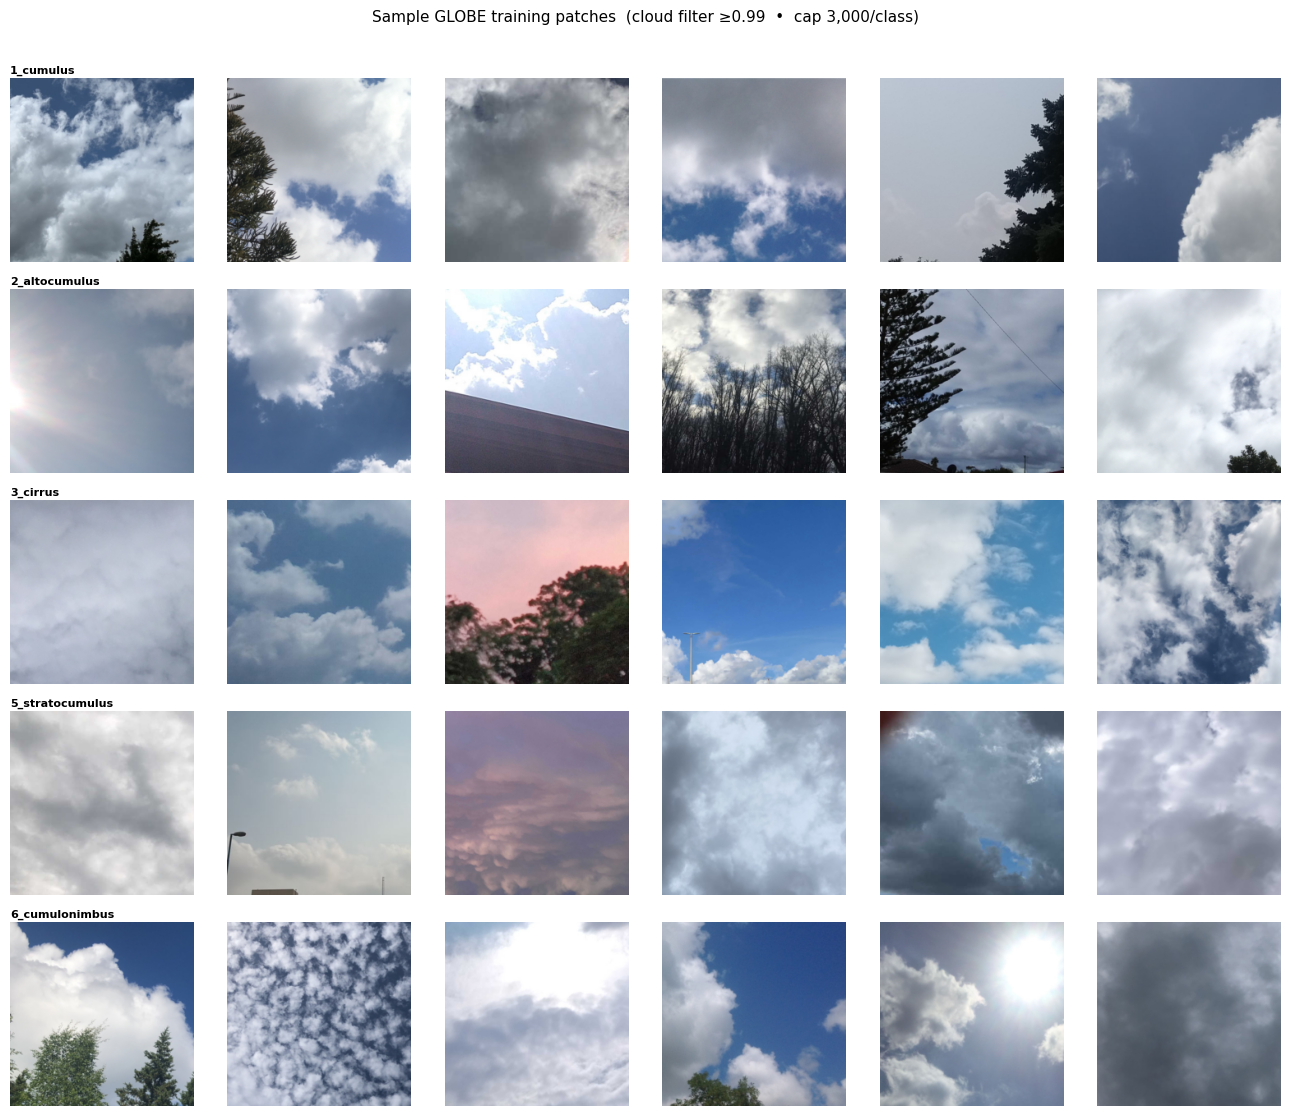

In [37]:

# ── Visualise sample patches that passed the cloud filter and cap ─────────────
PATCHES_PER_CLASS = 6
_rng_vis = _random.Random(0)

vis_by_class = {}
for sample in globe_train_patches.samples:
    vis_by_class.setdefault(sample[1], []).append(sample)

n_rows = len(vis_by_class)
n_cols = PATCHES_PER_CLASS

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2, n_rows * 2.2))
fig.suptitle(
    f'Sample GLOBE training patches  '
    f'(cloud filter ≥{CLOUD_THRESHOLD}  •  cap {MAX_PATCHES_PER_CLASS:,}/class)',
    fontsize=11, y=1.01
)

for row_idx, cls_idx in enumerate(sorted(vis_by_class)):
    pool   = vis_by_class[cls_idx]
    chosen = _rng_vis.sample(pool, min(PATCHES_PER_CLASS, len(pool)))
    for col_idx, (path, label, box) in enumerate(chosen):
        img  = Image.open(path).convert('RGB')
        crop = img.crop(box).resize((OUTPUT_SIZE, OUTPUT_SIZE), Image.BILINEAR)
        ax   = axes[row_idx][col_idx]
        ax.imshow(crop)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(class_names[cls_idx], loc='left', fontsize=8,
                         pad=3, fontweight='bold')

plt.tight_layout()
plt.show()


In [38]:
class GCDDataset(Dataset):
    def __init__(self, paths, encoded_labels, transform=None):
        self.paths          = list(paths)
        self.encoded_labels = list(encoded_labels)
        self.transform      = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.encoded_labels[idx]


gcd_train_set = GCDDataset(
    gcd_split['train'][0], gcd_split['train'][1], gcd_train_transforms)
gcd_val_set   = GCDDataset(
    gcd_split['val'][0],   gcd_split['val'][1],   eval_transforms)
gcd_test_set  = GCDDataset(
    gcd_split['test'][0],  gcd_split['test'][1],  eval_transforms)

print('GCD dataset sizes (clearsky + mixed):')
print(f'  train: {len(gcd_train_set):,}  val: {len(gcd_val_set):,}  test: {len(gcd_test_set):,}')

GCD dataset sizes (clearsky + mixed):
  train: 1,998  val: 500  test: 2,196


In [39]:
from torch.utils.data import DataLoader, WeightedRandomSampler, ConcatDataset

train_set = ConcatDataset([globe_train_patches, gcd_train_set])
valid_set = ConcatDataset([globe_val_patches,   gcd_val_set])
test_set  = ConcatDataset([globe_test_patches,  gcd_test_set])

train_labels_list = (
    [s[1] for s in globe_train_patches.samples] +
    list(gcd_train_set.encoded_labels)
)

class_counts  = np.bincount(train_labels_list, minlength=n_classes)
class_weights = 1.0 / class_counts
sample_weights = torch.tensor(
    [class_weights[l] for l in train_labels_list], dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# num_workers=0 required locally — T.Lambda in transforms cannot be pickled
train_loader = DataLoader(train_set, batch_size=64, sampler=sampler,  num_workers=0)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False,    num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False,    num_workers=0)

print('Combined dataset sizes:')
print(f'  train: {len(train_set):,}'
      f'  (GLOBE patches: {len(globe_train_patches):,}  GCD: {len(gcd_train_set):,})')
print(f'  val:   {len(valid_set):,}'
      f'  (GLOBE patches: {len(globe_val_patches):,}    GCD: {len(gcd_val_set):,})')
print(f'  test:  {len(test_set):,}'
      f'  (GLOBE patches: {len(globe_test_patches):,}   GCD: {len(gcd_test_set):,})')
print('\nClass counts in training set:')
for i, cnt in enumerate(class_counts):
    print(f'  {class_names[i]:25s}  {cnt:,}')

Combined dataset sizes:
  train: 16,998  (GLOBE patches: 15,000  GCD: 1,998)
  val:   5,085  (GLOBE patches: 4,585    GCD: 500)
  test:  11,341  (GLOBE patches: 9,145   GCD: 2,196)

Class counts in training set:
  1_cumulus                  3,000
  2_altocumulus              3,000
  3_cirrus                   3,000
  4_clearsky                 1,720
  5_stratocumulus            3,000
  6_cumulonimbus             3,000
  7_mixed                    278


In [40]:
class TopBlock(nn.Module):
    """
    Custom classification head from CloudDenseNet (Li et al., Sensors 2023).

    BN -> Dropout -> Linear(1024, hidden) -> ReLU -> BN -> Dropout -> Linear(hidden, n_classes)
    Weights initialised with LeCun uniform distribution.
    """
    def __init__(self, in_features: int, n_classes: int,
                 hidden_dim: int = 512, dropout: float = 0.5):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(p=dropout / 2),
            nn.Linear(hidden_dim, n_classes),
        )
        self._lecun_init()

    def _lecun_init(self):
        for m in self.block:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='linear')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.block(x)


weights = torchvision.models.DenseNet121_Weights.IMAGENET1K_V1
model   = torchvision.models.densenet121(weights=weights).to(device)

for param in model.parameters():
    param.requires_grad = False

model.classifier = TopBlock(in_features=1024, n_classes=n_classes).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print('DenseNet121 loaded (ImageNet weights, backbone frozen)')
print(f'Classes ({n_classes}): {class_names}')
print(f'Trainable params: {trainable:,} / {total:,}')

DenseNet121 loaded (ImageNet weights, backbone frozen)
Classes (7): ['1_cumulus' '2_altocumulus' '3_cirrus' '4_clearsky' '5_stratocumulus'
 '6_cumulonimbus' '7_mixed']
Trainable params: 531,463 / 7,485,319


In [41]:
import torchmetrics


def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            metric.update(model(X_batch), y_batch)
    return metric.compute()

In [42]:
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017).
    Down-weights easy examples so the model focuses on hard ones.
    gamma=0 reduces to standard cross-entropy.
    """
    def __init__(self, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction='none')
        p_t = torch.exp(-ce)
        loss = ((1.0 - p_t) ** self.gamma) * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


focal_loss = FocalLoss(gamma=2.0).to(device)
print('FocalLoss ready (gamma=2.0)')

FocalLoss ready (gamma=2.0)


In [43]:
import time
from tqdm.auto import tqdm


def train_phase(model, optimizer, loss_fn, metric,
                train_loader, valid_loader,
                n_epochs, patience, checkpoint_path, phase_label=''):
    """
    Run one phase of the gradual-unfreeze schedule.

    Keeps frozen BatchNorm layers in eval mode so their running statistics
    are not corrupted; only BN layers with requires_grad=True are trained.
    Best weights are saved to checkpoint_path and restored before returning.
    """
    history    = {'train_losses': [], 'train_metrics': [], 'valid_metrics': []}
    best_val   = 0.0
    no_improve = 0

    for epoch in range(n_epochs):
        t0 = time.time()

        model.eval()
        model.classifier.train()
        for module in model.modules():
            if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
                if any(p.requires_grad for p in module.parameters()):
                    module.train()

        total_loss = 0.0
        metric.reset()

        for X_batch, y_batch in tqdm(train_loader,
                                     desc=f'Epoch {epoch+1}/{n_epochs}',
                                     leave=False, unit='batch'):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            metric.update(y_pred, y_batch)

        train_loss = total_loss / len(train_loader)
        train_acc  = metric.compute().item()
        val_acc    = evaluate_tm(model, valid_loader, metric).item()
        elapsed    = (time.time() - t0) / 60.0

        history['train_losses'].append(train_loss)
        history['train_metrics'].append(train_acc)
        history['valid_metrics'].append(val_acc)

        star = ' *' if val_acc > best_val else ''
        print(f'[{phase_label}] Epoch {epoch+1}/{n_epochs} | '
              f'loss: {train_loss:.4f} | '
              f'train: {train_acc:.4f} | '
              f'val: {val_acc:.4f} | '
              f'{elapsed:.2f} min{star}')

        if val_acc > best_val:
            best_val   = val_acc
            no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch+1} (best val: {best_val:.4f})')
                break

    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    return history, best_val

In [44]:
accuracy    = torchmetrics.Accuracy(task='multiclass', num_classes=n_classes).to(device)
CKPT        = 'best_cloudensenet_18.pt'
all_history = []

# -- Phase 1: TopBlock only, LR = 1e-4, 10 epochs ----------------------------
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-4, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=10, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 1 (head, 1e-4)')
all_history.append(h)

# -- Phase 2: TopBlock only, LR = 1e-5, 10 epochs ----------------------------
opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-5, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=10, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 2 (head, 1e-5)')
all_history.append(h)

# -- Phase 3: unfreeze DenseBlock3+, backbone LR = 5e-5, 20 epochs -----------
unfreeze_from = ['features.denseblock3', 'features.transition3',
                 'features.denseblock4', 'features.norm5']
for name, param in model.named_parameters():
    if any(name.startswith(p) for p in unfreeze_from):
        param.requires_grad = True

backbone_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and not n.startswith('classifier')]
head_params     = list(model.classifier.parameters())

opt = torch.optim.AdamW([
    {'params': head_params,     'lr': 1e-5},
    {'params': backbone_params, 'lr': 5e-5},
], weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 3 (denseblock3+, 5e-5)')
all_history.append(h)

# -- Phase 4: same unfrozen scope, backbone LR = 1e-5, 20 epochs -------------
opt = torch.optim.AdamW([
    {'params': head_params,     'lr': 1e-5},
    {'params': backbone_params, 'lr': 1e-5},
], weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 4 (denseblock3+, 1e-5)')
all_history.append(h)

# -- Phase 5: all layers, LR = 1e-6, 20 epochs --------------------------------
for param in model.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(model.parameters(), lr=1e-6, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 5 (all, 1e-6)')
all_history.append(h)

[Phase 1 (head, 1e-4)] Epoch 1/10 | loss: 1.2530 | train: 0.4052 | val: 0.4051 | 4.17 min *


[Phase 1 (head, 1e-4)] Epoch 2/10 | loss: 1.0010 | train: 0.4729 | val: 0.4165 | 4.10 min *


[Phase 1 (head, 1e-4)] Epoch 3/10 | loss: 0.9242 | train: 0.4866 | val: 0.4297 | 3.99 min *


[Phase 1 (head, 1e-4)] Epoch 4/10 | loss: 0.8651 | train: 0.4984 | val: 0.4326 | 4.08 min *


[Phase 1 (head, 1e-4)] Epoch 5/10 | loss: 0.8333 | train: 0.5060 | val: 0.4413 | 4.03 min *


...

[Phase 5 (all, 1e-6)] Epoch 16/20 | loss: 0.5203 | train: 0.6308 | val: 0.4645 | 5.82 min *


[Phase 5 (all, 1e-6)] Epoch 17/20 | loss: 0.5185 | train: 0.6283 | val: 0.4616 | 5.93 min


[Phase 5 (all, 1e-6)] Epoch 18/20 | loss: 0.5182 | train: 0.6337 | val: 0.4627 | 5.88 min


[Phase 5 (all, 1e-6)] Epoch 19/20 | loss: 0.5071 | train: 0.6388 | val: 0.4623 | 5.89 min


[Phase 5 (all, 1e-6)] Epoch 20/20 | loss: 0.5241 | train: 0.6305 | val: 0.4645 | 17.44 min


In [46]:
test_acc = evaluate_tm(model, test_loader, accuracy)
print(f'Final test accuracy: {test_acc:.4f}')

Final test accuracy: 0.5067


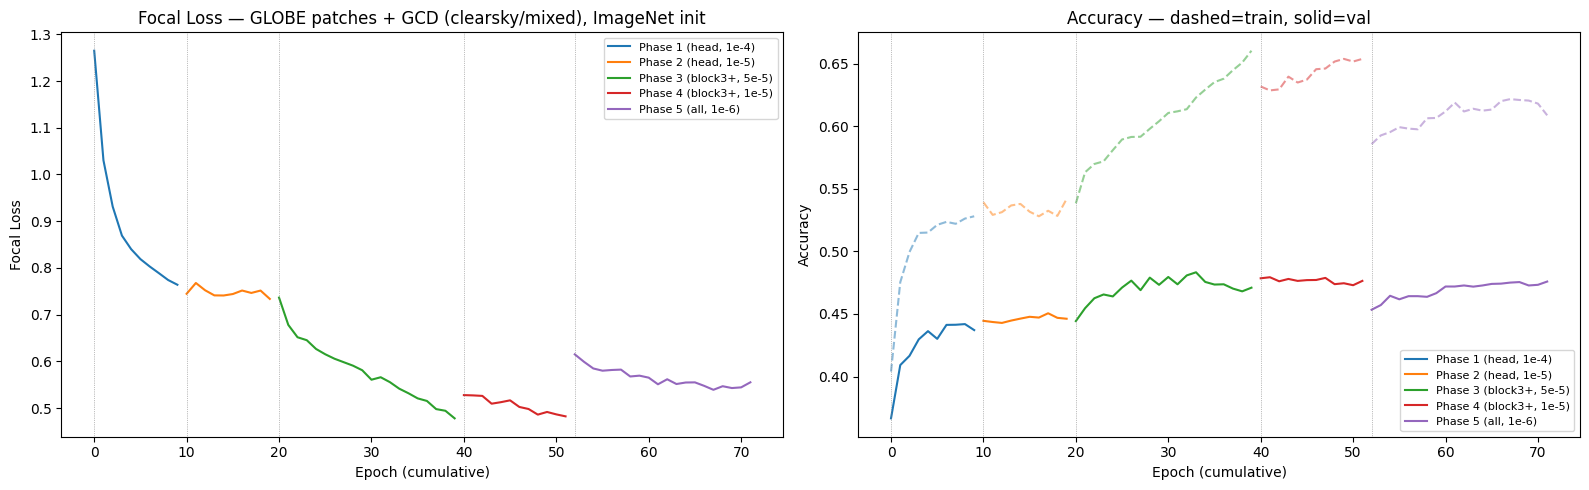

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = [
    'Phase 1 (head, 1e-4)',
    'Phase 2 (head, 1e-5)',
    'Phase 3 (block3+, 5e-5)',
    'Phase 4 (block3+, 1e-5)',
    'Phase 5 (all, 1e-6)',
]

offset = 0
for h, label, color in zip(all_history, labels, colors):
    xs = list(range(offset, offset + len(h['train_losses'])))
    axes[0].plot(xs, h['train_losses'], color=color, label=label)
    axes[1].plot(xs, h['train_metrics'], color=color, linestyle='--', alpha=0.5)
    axes[1].plot(xs, h['valid_metrics'],  color=color, label=label)
    for ax in axes:
        ax.axvline(x=offset, color='grey', linewidth=0.5, linestyle=':')
    offset += len(h['train_losses'])

axes[0].set_title('Focal Loss — GLOBE patches + GCD (clearsky/mixed), ImageNet init')
axes[0].set_xlabel('Epoch (cumulative)')
axes[0].set_ylabel('Focal Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Accuracy — dashed=train, solid=val')
axes[1].set_xlabel('Epoch (cumulative)')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

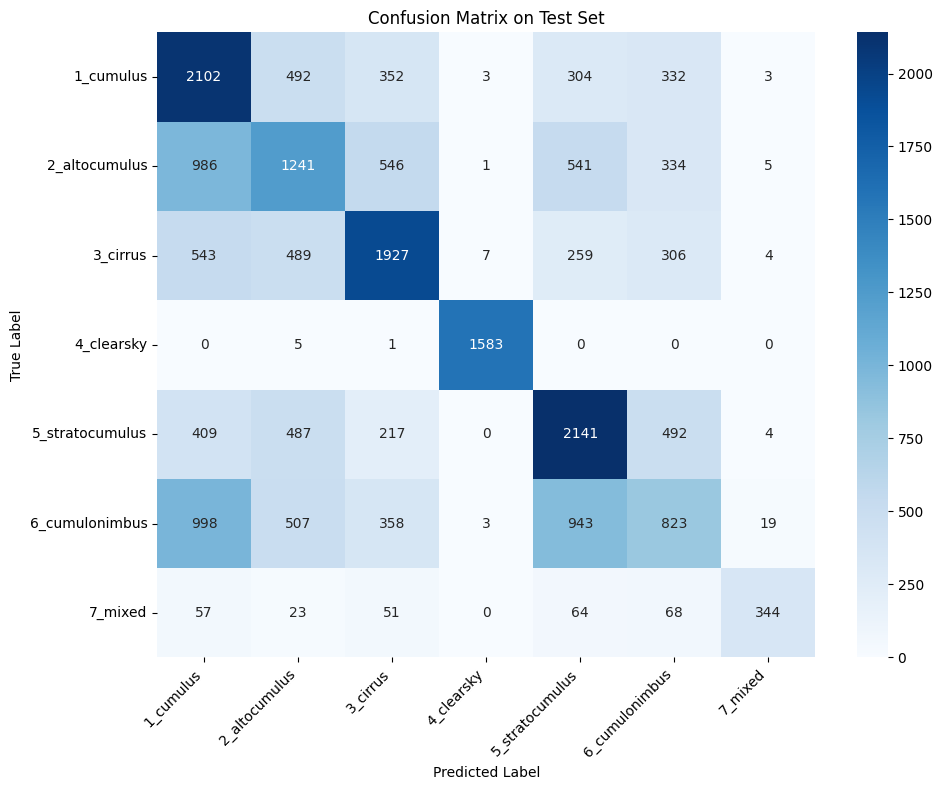

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = torch.argmax(model(X_batch), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()